<a href="https://colab.research.google.com/github/Jaum36/atividade-filtro-sobel-topicos1/blob/main/Topicos1_2026_1_Tarefa1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 1 -- Tópicos para Computação 1 -- 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 03 de março de 2026

## Descrição

A atividade consiste em usar um extrator de bordas clássico, o filtro Sobel, em duas imagens, visualizando o resultado e construindo o mapa/vetor de características resultante dessa extração. Visa ilustrar o processo manual e as operações matemáticas envolvidas em algoritmos extratores de características tradicionais, bem como introduzir competências técnicas e tecnológicas para realização de operações como a convolução em ambiente computacional.

## Prazos importantes

- Data de entrega: 06/03/2026
- Modo de entrega: Google Classroom
- Estratégia de desenvolvimento: Duplas


In [ ]:
## Espaço para importar bibliotecas

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

### Abrir imagem

Utilizando o pacote opencv (cv2) e a função imread, abra uma imagem de sua preferência. A imagem deve ser aberta em tons de cinza Como exemplo, há as imagens 'badbunny' e 'deepfake'. Em seguida, visualize a imagem após a abertura.

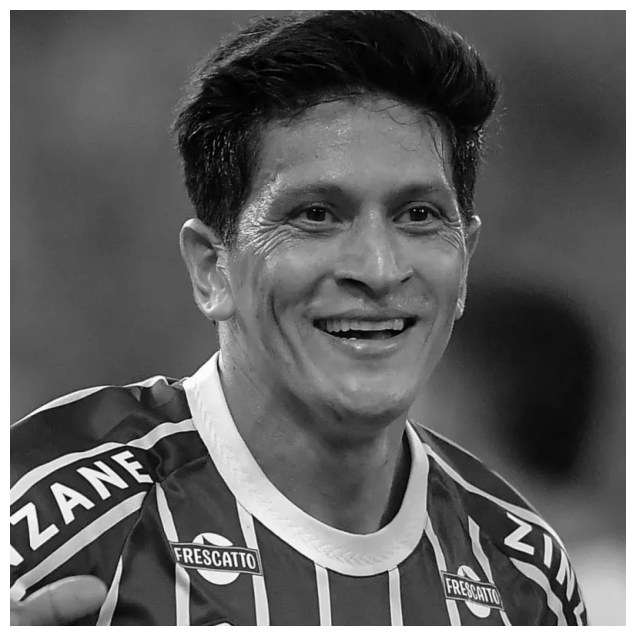

In [ ]:
# O parâmetro '0' visto na documentação é para ler a imagem em 'GRAYSCALE'
img = cv2.imread("cano.webp", 0)

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0)

## Conversão da imagem

Para que a imagem possa ser processada com o Pytorch, ela precisa ser um tensor de 4 dimensões.

Esse tensor possui a seguinte estrutura [B, C, H, W], em que:
- Batch: denota quantas imagens estão sendo processadas de uma vez (B = 1).
- Channel: denota quantos canais de cor (C = 1 para Cinza, C = 3 para RGB).
- Height: altura da imagem em pixels.
- Width: largura da imagem em pixels.

Use o comando:

img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0)

1. torch.from_numpy(img): Converte a matriz do NumPy do Opencv em um tensor do PyTorch
2. float(): converte de uint8 para float
3. unsqueeze(0): adiciona 1 dimensão, i.e., [1, H, W]
4. unsqueeze(0): adiciona outra dimensão, i.e., [1, 1, H, W]

Ao final, temos o tensor desejado.   
Imprima o tipo e sua forma (shape)  
Verifique as dimensões da imagem  

In [ ]:
print(f"DType: {img_tensor.dtype}")
print(f"Shape: {img_tensor.shape}")
print(f"Heigh: {img_tensor.shape[2]}")
print(f"Width: {img_tensor.shape[3]}")

DType: torch.float32
Shape: torch.Size([1, 1, 800, 800])
Heigh: 800
Width: 800


## Filtro Sobel

O filtro Sobel é uma operação utilizada em processamento de imagem, aplicada sobretudo em algoritmos de detecção de contornos. Ele calcula o gradiente da intensidade da imagem em cada ponto, dando a direcção da maior variação de claro para escuro e a quantidade de variação nessa direcção. Assim, obtém-se uma noção de como varia a luminosidade em cada ponto, de forma mais suave ou abrupta. Com isto consegue-se estimar a presença de uma transição claro-escuro e de qual a orientação desta. Como as variações claro-escuro intensas correspondem a fronteiras bem definidas entre objectos, consegue-se fazer a detecção de contornos.

O Filtro Sobel utiliza duas matrizes $3 \times 3$ que são convoluídas com a imagem original $A$ para calcular a magnitude e a direção do gradiente, da seguinte forma:


$$
\mathbf{G_x} = \begin{bmatrix}
-1 & 0 & +1 \\
-2 & 0 & +2 \\
-1 & 0 & +1
\end{bmatrix} * \mathbf{A}
\quad \text{e} \quad
\mathbf{G_y} = \begin{bmatrix}
+1 & +2 & +1 \\
0 & 0 & 0 \\
-1 & -2 & -1
\end{bmatrix} * \mathbf{A}
$$

Portanto a magnitude, $\mathbf{G}$, e a direcção, $\mathbf{\Theta}$, do gradiente são dados por:

$$
\begin{aligned}
\mathbf{G} &= \sqrt{\mathbf{G_x}^2 + \mathbf{G_y}^2} \\
\mathbf{\Theta} &= \arctan\left(\frac{\mathbf{G_y}}{\mathbf{G_x}}\right)
\end{aligned}
$$


### Definição dos tensores para as matrizes do Filtro Sobel

Para proceder com a aplicação do Filtro Sobel, crie dois tensores (1,1,3,3) com as matrizes $K_x$ e $K_y$ dadas a seguir:

$$
K_x = \begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$$

$$K_y = \begin{bmatrix}
+1 & +2 & +1 \\
0 & 0 & 0 \\
-1 & -2 & -1
\end{bmatrix}
$$

In [ ]:
Kx = np.array([[-1,0,1], [-2, 0, 2], [-1, 0, 1]])
Ky = np.array([[1, 2, 1], [0,0,0], [-1,-2,-1]])

tensor_Kx = torch.from_numpy(Kx).float().unsqueeze(0).unsqueeze(0)
tensor_Ky = torch.from_numpy(Ky).float().unsqueeze(0).unsqueeze(0)

print(f"Shape do Tensor de Kx: {tensor_Kx.shape}")
print(f"Shape do Tensor de Ky: {tensor_Ky.shape}")

Shape do Tensor de Kx: torch.Size([1, 1, 3, 3])
Shape do Tensor de Ky: torch.Size([1, 1, 3, 3])


### Entendendo a Convolução

No contexto de processamento de imagens e visão computacional, a convolução é uma operação matemática em que uma pequena matriz, chaamda filtro ou kernel é "deslizada" sobre a imagem original para extrair características específicas.

- Kernel (Filtro): É uma matriz pequena (como o $G_x$ e $G_y$ no filtro Sobel) que contém pesos matemáticos definidos para detectar padrões
- Operação de convolução: Em cada posição da imagem, o kernel é sobreposto aos pixels da imagem. Multiplica-se cada peso do kernel pelo valor do pixel correspondente e somam-se todos esses resultados.
- Mapa de Características: O resultado dessa soma torna-se um único pixel na nova imagem (o "feature map"). Esse novo valor indica a presença ou a força da característica naquele local exato.

#### Exercício de Convolução Manual

Considere a matriz da imagem $\mathbf{M}$ e o filtro $\mathbf{F}$ a seguir:

$$
\mathbf{M} = \begin{bmatrix}
10 & 10 & 0 & 0 \\
10 & 10 & 0 & 0 \\
10 & 10 & 0 & 0 \\
10 & 10 & 0 & 0
\end{bmatrix}
\quad , \quad
\mathbf{F} = \begin{bmatrix}
-1 & 0 & 1 \\
-1 & 0 & 1 \\
-1 & 0 & 1
\end{bmatrix}
$$

**Tarefa:**
Calcule o mapa de características resultante da convolução $(F * M)$.

**Equação Auxiliar:**
$$y[i, j] = \sum_{m} \sum_{n} \mathbf{M}[i-m, j-n] \cdot \mathbf{F}[m, n]$$

In [ ]:
M = np.array([[10,10,0,0], [10,10,0,0], [10,10,0,0], [10,10,0,0]])
FMatriz = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

M_x, M_y = M.shape
F_x, F_y = FMatriz.shape

X = np.zeros((2,2))

for i in range(2):
  for j in range(2):
    soma = 0

    for m in range(F_x):
      for n in range(F_y):
        M_linha = i + (F_x - 1 - m)
        M_coluna = j + (F_y - 1 - n)

        soma += M[M_linha, M_coluna] * FMatriz[m, n]

    X[i, j] = soma

print(f"Resultado da convolução:\n {X}")

Resultado da convolução:
 [[30. 30.]
 [30. 30.]]


#### Convolução no Pytorch

Utilize  
import torch.nn.functional as F  

e faça   
gx = F.conv2d(img_tensor, kx, padding=1)

Repita o mesmo para obter gy  

In [ ]:
tensor_Gx = F.conv2d(img_tensor, tensor_Kx, padding = 1)
tensor_Gy = F.conv2d(img_tensor, tensor_Ky, padding = 1)

### Magnitude do Gradiente

Calcule a magnitude do gradiente, dada como segue:

$$
\mathbf{G} = \sqrt{\mathbf{G_x}^2 + \mathbf{G_y}^2}
$$

Use a função torch.sqrt

In [ ]:
G_magnitude = torch.sqrt(tensor_Gx**2 + tensor_Gy**2)

### Orientação do gradiente

A orientação do  gradiente é dada por:

$$\mathbf{\Theta} = \arctan\left(\frac{\mathbf{G_y}}{\mathbf{G_x}}\right)$$

Use a função torch.atan2 e converta para graus, multiplicando por $180/\pi$
- Para $\pi$, use a constante do numpy

In [ ]:
orientacao = torch.atan2(tensor_Gy, tensor_Gx) * 180/np.pi

### Visualização do Resultado

- Para visualizar, converta os tensores para array numpy 2D.
- Normalize a magnitude para o intervalo $[0,255]$
- Utilize o espaço de cores hsv para mostrar a orientação do gradiente
- Exiba os resultados da magnitude e da orientação ao lado da imagem original, de forma comparativa

In [ ]:
G_magnitude_matriz_2d = G_magnitude.squeeze().cpu().numpy()
orientacao_matriz_2d = orientacao.squeeze().cpu().numpy()

G_magnitude_normalizada = (G_magnitude_matriz_2d - G_magnitude_matriz_2d.min()) / (G_magnitude_matriz_2d.max() - G_magnitude_matriz_2d.min()) * 255
G_magnitude_normalizada = G_magnitude_normalizada.astype(np.uint8)


In [ ]:
h, w = G_magnitude_matriz_2d.shape
hsv_imagem = np.zeros((h,w,3), dtype=np.uint8)

hsv_imagem[:, :, 0] = (orientacao_matriz_2d % 180).astype(np.uint8)
hsv_imagem[:, :, 1] = 255
hsv_imagem[: , : , 2] = G_magnitude_normalizada
hsv_bgr = cv2.cvtColor(hsv_imagem, cv2.COLOR_HSV2BGR)

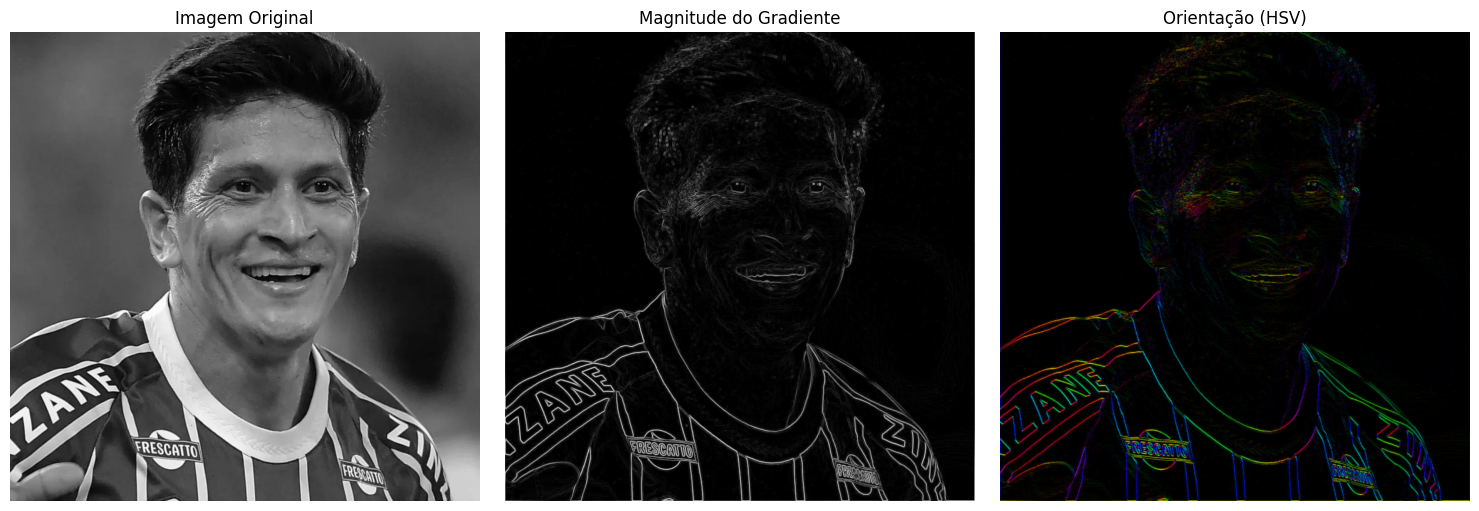

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Imagem Original')
axes[0].axis('off')

axes[1].imshow(G_magnitude_normalizada, cmap='gray')
axes[1].set_title('Magnitude do Gradiente')
axes[1].axis('off')

axes[2].imshow(hsv_bgr)
axes[2].set_title('Orientação (HSV)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Construa o vetor de características de Sobel

Observe que temos quatro matrizes além da imagem original (são elas, Gx, Gy, G e Theta). Observe que temos muito mais informação do que inicialmente começamos. Precisamos de um vetor de características global, que captura a essência das características da imagem:

### Flatten

Para obter um vetor (1D), precisamos "planificar" a matriz (2D):  
feat_magnitude = g.cpu().numpy().flatten()

### Dados Estatísticos

O vetor de características será obtido a partir de dados estatísticos da magnitude:
1. Calcule a média da magnitude: Indica a "quantidade" geral de bordas, de tal modo que uma imagem com muitas linhas terá uma média alta.
2. Calcule o desvio padrão da magnitude: Indica o contraste das bordas, isto é, diz se as bordas são todas parecidas ou se há grandes variações de intensidade.
3. Máximo: Identifica a borda mais forte encontrada na imagem.

### Concatenação

Concatene os vetores resultantes (magnitude e dados estatísticos), produzindo uma espécie de resumo das características da imagem avaliadas por Sobel

In [ ]:
G_magnitude_flatten = G_magnitude.cpu().numpy().flatten()

In [ ]:
G_magnitude_media = np.mean(G_magnitude_flatten)
G_magnitude_desvio_padrao = np.std(G_magnitude_flatten)
G_magnitude_maximo = np.max(G_magnitude_flatten)

print(f"Média: {G_magnitude_media}")
print(f"Desvio Padrão: {G_magnitude_desvio_padrao}")
print(f"Máximo: {G_magnitude_maximo}")

Média: 43.170406341552734
Desvio Padrão: 103.07843780517578
Máximo: 993.909423828125


In [ ]:
vetor_caracteristicas = np.concatenate([ G_magnitude_flatten, [G_magnitude_media, G_magnitude_desvio_padrao, G_magnitude_maximo]])
print(f"Tamanho do vetor de características: {vetor_caracteristicas.shape[0]}")

Tamanho do vetor de características: 640003


### Argumente

O vetor de características resultante possui maior dimensão do que a imagem original, além de ter demandado processamento para ser obtido. Como ele pode ser útil em um contexto prático em uma tarefa de Visão Computacional? O esforço realizado vale a pena?

#### Argumentação:

A utilização de vetores de características, como os obtidos através do Filtro Sobel, é fundamental em tarefas de Visão Computacional pois permite a transição de dados brutos (intensidade de pixels) para informações semânticas estruturais (bordas e contornos).

Utilidade em Contexto Prático: No processamento de imagens, a maioria dos pixels em áreas homogêneas não contribui para a identificação de objetos. Ao extrair bordas, isolamos as descontinuidades que definem a geometria da cena. Isso torna o sistema mais robusto contra variações de iluminação e ruído, além de facilitar algoritmos de aprendizado de máquina (como Redes Neurais e SVMs) a encontrar fronteiras de decisão baseadas em formas e texturas, em vez de apenas cores.

Validade do Esforço: O esforço computacional e o aumento da dimensionalidade são plenamente justificados. Embora o volume de dados possa ser maior, a densidade de informação útil aumenta drasticamente. Representações baseadas em gradientes (como HOG ou as primeiras camadas de uma CNN) são a base para o estado da arte em reconhecimento de padrões, segmentação e detecção de objetos. Sem essa etapa de filtragem e abstração, os modelos seriam excessivamente sensíveis a mudanças irrelevantes no ambiente, comprometendo a precisão e a capacidade de generalização.

